In [1]:
import operator
import os
import re
import shutil
import sqlite3
import time
import uuid
from datetime import date, datetime
from typing import Annotated, Any, Callable, Optional, Union

import anthropic
import google.generativeai as genai
import instructor
import lancedb
import numpy as np
import openai
import pandas as pd
import pytz
import requests
from IPython.display import Image, display
from lancedb.embeddings import get_registry
from lancedb.pydantic import LanceModel, Vector
from langchain_core.messages import AnyMessage
from langchain_core.runnables import RunnableConfig, ensure_config
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel
from termcolor import colored
from typing_extensions import TypedDict

from dreamai.ai import (
    ModelName,
    Tool,
    assistant_message,
    chat_message,
    convert_lc_messages,
    create_tool_model,
    run_tool,
    system_message,
    user_message,
)

ask_gemini = instructor.from_gemini(
    client=genai.GenerativeModel(model_name=ModelName.GEMINI_FLASH)
)

ask_oai = instructor.from_openai(openai.OpenAI())

ask_cld = instructor.from_anthropic(
    anthropic.Anthropic(), mode=instructor.Mode.ANTHROPIC_TOOLS
)

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
LANCE_URI = "lance/support/"
EMS_MODEL = "BAAI/bge-small-en-v1.5"
TABLE_NAME = "support_table"

In [3]:
class VectorStoreRetriever:
    def __init__(
        self,
        docs: list[str],
        lance_uri: str = LANCE_URI,
        ems_model: str = EMS_MODEL,
        table_name: str = TABLE_NAME,
        drop_table: bool = True,
    ):
        self.lance_uri = lance_uri
        self.table_name = table_name
        self.db = lancedb.connect(lance_uri)
        if drop_table:
            self.db.drop_table(table_name, ignore_missing=True)  # type: ignore
        model = (
            get_registry()
            .get("sentence-transformers")
            .create(name=ems_model, device="cuda:0")
        )

        class Document(LanceModel):
            text: str = model.SourceField()
            vector: Vector(model.ndims()) = model.VectorField()  # type: ignore

        table = self.db.create_table(table_name, schema=Document, exist_ok=True)
        table.add([{"text": doc} for doc in docs])

    @classmethod
    def from_docs(
        cls,
        docs: list[str],
        lance_uri: str = LANCE_URI,
        ems_model: str = EMS_MODEL,
        table_name: str = TABLE_NAME,
        drop_table: bool = True,
    ) -> "VectorStoreRetriever":
        return cls(
            docs=docs,
            lance_uri=lance_uri,
            ems_model=ems_model,
            table_name=table_name,
            drop_table=drop_table,
        )

    def search(self, query: str, limit: int = 2) -> pd.DataFrame:
        table = self.db.open_table(name=self.table_name)
        return table.search(query=query).limit(limit).to_pandas()

In [4]:
# db_url = "https://storage.googleapis.com/benchmarks-artifacts/travel-db/travel2.sqlite"
# local_file = "travel2.sqlite"
# # The backup lets us restart for each tutorial section
# backup_file = "travel2.backup.sqlite"
# overwrite = False
# if overwrite or not os.path.exists(local_file):
#     response = requests.get(db_url)
#     response.raise_for_status()  # Ensure the request was successful
#     with open(local_file, "wb") as f:
#         f.write(response.content)
#     # Backup - we will use this to "reset" our DB in each section
#     shutil.copy(local_file, backup_file)
# # Convert the flights to present time for our tutorial
# conn = sqlite3.connect(local_file)
# cursor = conn.cursor()

# tables = pd.read_sql(
#     "SELECT name FROM sqlite_master WHERE type='table';", conn
# ).name.tolist()
# tdf = {}
# for t in tables:
#     tdf[t] = pd.read_sql(f"SELECT * from {t}", conn)

# example_time = pd.to_datetime(
#     tdf["flights"]["actual_departure"].replace("\\N", pd.NaT)
# ).max()
# current_time = pd.to_datetime("now").tz_localize(example_time.tz)
# time_diff = current_time - example_time

# tdf["bookings"]["book_date"] = (
#     pd.to_datetime(tdf["bookings"]["book_date"].replace("\\N", pd.NaT), utc=True)
#     + time_diff
# )

# datetime_columns = [
#     "scheduled_departure",
#     "scheduled_arrival",
#     "actual_departure",
#     "actual_arrival",
# ]
# for column in datetime_columns:
#     tdf["flights"][column] = (
#         pd.to_datetime(tdf["flights"][column].replace("\\N", pd.NaT)) + time_diff
#     )

# for table_name, df in tdf.items():
#     df.to_sql(table_name, conn, if_exists="replace", index=False)
# del df
# del tdf
# conn.commit()
# conn.close()

# db = local_file  # We'll be using this local file as our DB in this tutorial

In [5]:
db = "travel2.sqlite"
backup_file = "travel2.backup.sqlite"

In [6]:
response = requests.get(
    "https://storage.googleapis.com/benchmarks-artifacts/travel-db/swiss_faq.md"
)
response.raise_for_status()
faq_text = response.text

In [7]:
faqs = [faq.strip() for faq in faq_text.split("##") if faq.strip()]

In [8]:
retriever = VectorStoreRetriever.from_docs(docs=faqs, table_name="faqs_table")

/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [9]:
def lookup_policy(query: str, limit: int = 2) -> str:
    """Consult the company policies to check whether certain options are permitted.
    Use this before making any flight changes performing other 'write' events."""
    docs = retriever.search(query, limit=limit)
    return "\n\n".join(docs.text)


def fetch_user_flight_information() -> list[dict]:
    """Fetch all tickets for the user along with corresponding flight information and seat assignments.

    Returns:
        A list of dictionaries where each dictionary contains the ticket details,
        associated flight details, and the seat assignments for each ticket belonging to the user.
    """
    config = ensure_config()  # Fetch from the context
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")

    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = """
    SELECT 
        t.ticket_no, t.book_ref,
        f.flight_id, f.flight_no, f.departure_airport, f.arrival_airport, f.scheduled_departure, f.scheduled_arrival,
        bp.seat_no, tf.fare_conditions
    FROM 
        tickets t
        JOIN ticket_flights tf ON t.ticket_no = tf.ticket_no
        JOIN flights f ON tf.flight_id = f.flight_id
        JOIN boarding_passes bp ON bp.ticket_no = t.ticket_no AND bp.flight_id = f.flight_id
    WHERE 
        t.passenger_id = ?
    """
    cursor.execute(query, (passenger_id,))
    rows = cursor.fetchall()
    column_names = [column[0] for column in cursor.description]
    results = [dict(zip(column_names, row)) for row in rows]

    cursor.close()
    conn.close()

    return results


def search_flights(
    departure_airport: Optional[str] = None,
    arrival_airport: Optional[str] = None,
    start_time: Optional[date | datetime] = None,
    end_time: Optional[date | datetime] = None,
    limit: int = 20,
) -> list[dict]:
    """Search for flights based on departure airport, arrival airport, and departure time range."""
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM flights WHERE 1 = 1"
    params = []

    if departure_airport:
        query += " AND departure_airport = ?"
        params.append(departure_airport)

    if arrival_airport:
        query += " AND arrival_airport = ?"
        params.append(arrival_airport)

    if start_time:
        query += " AND scheduled_departure >= ?"
        params.append(start_time)

    if end_time:
        query += " AND scheduled_departure <= ?"
        params.append(end_time)
    query += " LIMIT ?"
    params.append(limit)
    cursor.execute(query, params)
    rows = cursor.fetchall()
    column_names = [column[0] for column in cursor.description]
    results = [dict(zip(column_names, row)) for row in rows]

    cursor.close()
    conn.close()

    return results


def update_ticket_to_new_flight(ticket_no: str, new_flight_id: int) -> str:
    """Update the user's ticket to a new valid flight."""
    config = ensure_config()
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")

    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "SELECT departure_airport, arrival_airport, scheduled_departure FROM flights WHERE flight_id = ?",
        (new_flight_id,),
    )
    new_flight = cursor.fetchone()
    if not new_flight:
        cursor.close()
        conn.close()
        return "Invalid new flight ID provided."
    column_names = [column[0] for column in cursor.description]
    new_flight_dict = dict(zip(column_names, new_flight))
    timezone = pytz.timezone("Etc/GMT-3")
    current_time = datetime.now(tz=timezone)
    departure_time = datetime.strptime(
        new_flight_dict["scheduled_departure"], "%Y-%m-%d %H:%M:%S.%f%z"
    )
    time_until = (departure_time - current_time).total_seconds()
    if time_until < (3 * 3600):
        return f"Not permitted to reschedule to a flight that is less than 3 hours from the current time. Selected flight is at {departure_time}."

    cursor.execute(
        "SELECT flight_id FROM ticket_flights WHERE ticket_no = ?", (ticket_no,)
    )
    current_flight = cursor.fetchone()
    if not current_flight:
        cursor.close()
        conn.close()
        return "No existing ticket found for the given ticket number."

    # Check the signed-in user actually has this ticket
    cursor.execute(
        "SELECT * FROM tickets WHERE ticket_no = ? AND passenger_id = ?",
        (ticket_no, passenger_id),
    )
    current_ticket = cursor.fetchone()
    if not current_ticket:
        cursor.close()
        conn.close()
        return f"Current signed-in passenger with ID {passenger_id} not the owner of ticket {ticket_no}"

    # In a real application, you'd likely add additional checks here to enforce business logic,
    # like "does the new departure airport match the current ticket", etc.
    # While it's best to try to be *proactive* in 'type-hinting' policies to the LLM
    # it's inevitably going to get things wrong, so you **also** need to ensure your
    # API enforces valid behavior
    cursor.execute(
        "UPDATE ticket_flights SET flight_id = ? WHERE ticket_no = ?",
        (new_flight_id, ticket_no),
    )
    conn.commit()

    cursor.close()
    conn.close()
    return "Ticket successfully updated to new flight."


def cancel_ticket(ticket_no: str) -> str:
    """Cancel the user's ticket and remove it from the database."""
    config = ensure_config()
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "SELECT flight_id FROM ticket_flights WHERE ticket_no = ?", (ticket_no,)
    )
    existing_ticket = cursor.fetchone()
    if not existing_ticket:
        cursor.close()
        conn.close()
        return "No existing ticket found for the given ticket number."

    # Check the signed-in user actually has this ticket
    cursor.execute(
        "SELECT flight_id FROM tickets WHERE ticket_no = ? AND passenger_id = ?",
        (ticket_no, passenger_id),
    )
    current_ticket = cursor.fetchone()
    if not current_ticket:
        cursor.close()
        conn.close()
        return f"Current signed-in passenger with ID {passenger_id} not the owner of ticket {ticket_no}"

    cursor.execute("DELETE FROM ticket_flights WHERE ticket_no = ?", (ticket_no,))
    conn.commit()

    cursor.close()
    conn.close()
    return "Ticket successfully cancelled."


def search_car_rentals(
    location: Optional[str] = None,
    name: Optional[str] = None,
    price_tier: Optional[str] = None,
    start_date: Optional[Union[datetime, date]] = None,
    end_date: Optional[Union[datetime, date]] = None,
) -> list[dict]:
    """
    Search for car rentals based on location, name, price tier, start date, and end date.

    Args:
        location (Optional[str]): The location of the car rental. Defaults to None.
        name (Optional[str]): The name of the car rental company. Defaults to None.
        price_tier (Optional[str]): The price tier of the car rental. Defaults to None.
        start_date (Optional[Union[datetime, date]]): The start date of the car rental. Defaults to None.
        end_date (Optional[Union[datetime, date]]): The end date of the car rental. Defaults to None.

    Returns:
        list[dict]: A list of car rental dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM car_rentals WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    # For our tutorial, we will let you match on any dates and price tier.
    # (since our toy dataset doesn't have much data)
    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]


def book_car_rental(rental_id: int) -> str:
    """
    Book a car rental by its ID.

    Args:
        rental_id (int): The ID of the car rental to book.

    Returns:
        str: A message indicating whether the car rental was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE car_rentals SET booked = 1 WHERE id = ?", (rental_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully booked."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."


def update_car_rental(
    rental_id: int,
    start_date: Optional[Union[datetime, date]] = None,
    end_date: Optional[Union[datetime, date]] = None,
) -> str:
    """
    Update a car rental's start and end dates by its ID.

    Args:
        rental_id (int): The ID of the car rental to update.
        start_date (Optional[Union[datetime, date]]): The new start date of the car rental. Defaults to None.
        end_date (Optional[Union[datetime, date]]): The new end date of the car rental. Defaults to None.

    Returns:
        str: A message indicating whether the car rental was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    if start_date:
        cursor.execute(
            "UPDATE car_rentals SET start_date = ? WHERE id = ?",
            (start_date, rental_id),
        )
    if end_date:
        cursor.execute(
            "UPDATE car_rentals SET end_date = ? WHERE id = ?", (end_date, rental_id)
        )

    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully updated."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."


def cancel_car_rental(rental_id: int) -> str:
    """
    Cancel a car rental by its ID.

    Args:
        rental_id (int): The ID of the car rental to cancel.

    Returns:
        str: A message indicating whether the car rental was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE car_rentals SET booked = 0 WHERE id = ?", (rental_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully cancelled."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."


def search_hotels(
    location: Optional[str] = None,
    name: Optional[str] = None,
    price_tier: Optional[str] = None,
    checkin_date: Optional[Union[datetime, date]] = None,
    checkout_date: Optional[Union[datetime, date]] = None,
) -> list[dict]:
    """
    Search for hotels based on location, name, price tier, check-in date, and check-out date.

    Args:
        location (Optional[str]): The location of the hotel. Defaults to None.
        name (Optional[str]): The name of the hotel. Defaults to None.
        price_tier (Optional[str]): The price tier of the hotel. Defaults to None. Examples: Midscale, Upper Midscale, Upscale, Luxury
        checkin_date (Optional[Union[datetime, date]]): The check-in date of the hotel. Defaults to None.
        checkout_date (Optional[Union[datetime, date]]): The check-out date of the hotel. Defaults to None.

    Returns:
        list[dict]: A list of hotel dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM hotels WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    # For the sake of this tutorial, we will let you match on any dates and price tier.
    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]


def book_hotel(hotel_id: int) -> str:
    """
    Book a hotel by its ID.

    Args:
        hotel_id (int): The ID of the hotel to book.

    Returns:
        str: A message indicating whether the hotel was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE hotels SET booked = 1 WHERE id = ?", (hotel_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully booked."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."


def update_hotel(
    hotel_id: int,
    checkin_date: Optional[Union[datetime, date]] = None,
    checkout_date: Optional[Union[datetime, date]] = None,
) -> str:
    """
    Update a hotel's check-in and check-out dates by its ID.

    Args:
        hotel_id (int): The ID of the hotel to update.
        checkin_date (Optional[Union[datetime, date]]): The new check-in date of the hotel. Defaults to None.
        checkout_date (Optional[Union[datetime, date]]): The new check-out date of the hotel. Defaults to None.

    Returns:
        str: A message indicating whether the hotel was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    if checkin_date:
        cursor.execute(
            "UPDATE hotels SET checkin_date = ? WHERE id = ?", (checkin_date, hotel_id)
        )
    if checkout_date:
        cursor.execute(
            "UPDATE hotels SET checkout_date = ? WHERE id = ?",
            (checkout_date, hotel_id),
        )

    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully updated."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."


def cancel_hotel(hotel_id: int) -> str:
    """
    Cancel a hotel by its ID.

    Args:
        hotel_id (int): The ID of the hotel to cancel.

    Returns:
        str: A message indicating whether the hotel was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE hotels SET booked = 0 WHERE id = ?", (hotel_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully cancelled."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."


def search_trip_recommendations(
    location: Optional[str] = None,
    name: Optional[str] = None,
    keywords: Optional[str] = None,
) -> list[dict]:
    """
    Search for trip recommendations based on location, name, and keywords.

    Args:
        location (Optional[str]): The location of the trip recommendation. Defaults to None.
        name (Optional[str]): The name of the trip recommendation. Defaults to None.
        keywords (Optional[str]): The keywords associated with the trip recommendation. Defaults to None.

    Returns:
        list[dict]: A list of trip recommendation dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM trip_recommendations WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    if keywords:
        keyword_list = keywords.split(",")
        keyword_conditions = " OR ".join(["keywords LIKE ?" for _ in keyword_list])
        query += f" AND ({keyword_conditions})"
        params.extend([f"%{keyword.strip()}%" for keyword in keyword_list])

    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]


def book_excursion(recommendation_id: int) -> str:
    """
    Book a excursion by its recommendation ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to book.

    Returns:
        str: A message indicating whether the trip recommendation was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET booked = 1 WHERE id = ?", (recommendation_id,)
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully booked."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."


def update_excursion(recommendation_id: int, details: str) -> str:
    """
    Update a trip recommendation's details by its ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to update.
        details (str): The new details of the trip recommendation.

    Returns:
        str: A message indicating whether the trip recommendation was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET details = ? WHERE id = ?",
        (details, recommendation_id),
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully updated."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."


def cancel_excursion(recommendation_id: int) -> str:
    """
    Cancel a trip recommendation by its ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to cancel.

    Returns:
        str: A message indicating whether the trip recommendation was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET booked = 0 WHERE id = ?", (recommendation_id,)
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully cancelled."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."


tools = {
    func.__name__: func
    for func in [
        lookup_policy,
        fetch_user_flight_information,
        search_flights,
        update_ticket_to_new_flight,
        cancel_ticket,
        search_car_rentals,
        book_car_rental,
        update_car_rental,
        cancel_car_rental,
        search_hotels,
        book_hotel,
        update_hotel,
        cancel_hotel,
        search_trip_recommendations,
        book_excursion,
        update_excursion,
        cancel_excursion,
    ]
}

In [10]:
tool_models = {name: create_tool_model(func=func) for name, func in tools.items()}

In [11]:
def system_template(
    user_info: dict[str, Any] = {"passenger_id": "123"}, time: datetime = datetime.now()
):
    return system_message(f"""\
You are a helpful customer support assistant for Swiss Airlines.
Use the provided tools to search for flights, company policies, accomodation, and other information to assist the user's queries.

Current user:
<User>
{user_info}
</User>
Current time: {time}\
""")

In [12]:
print(system_template({"passenger_id": 123})["content"])

You are a helpful customer support assistant for Swiss Airlines.
Use the provided tools to search for flights, company policies, accomodation, and other information to assist the user's queries.

Current user:
<User>
{'passenger_id': 123}
</User>
Current time: 2024-06-18 01:39:07.209351


In [13]:
class State(TypedDict):
    messages: Annotated[list[dict[str, Any]], operator.add]
    user_info: dict[str, Any]

In [14]:
def process_messages(messages: list[dict[str, Any]]) -> list[dict[str, Any]]:
    role_map = {
        "user": "user",
        "human": "user",
        "tool": "user",
        "ai": "assistant",
        "assistant": "assistant",
        "system": "system",
    }
    return [
        {"role": role_map[message["role"]], "content": message["content"]}
        for message in messages
        if not isinstance(message["content"], BaseModel)
    ]


def ai_node(
    state: State,
    tool_models: dict[str, Tool] = tool_models,  # type: ignore
    attempts: int = 3,
) -> dict[str, list[dict[str, Any]]]:
    # messages = convert_lc_messages(state["messages"])
    messages = state["messages"]
    if len(messages) == 0:
        messages.append(system_template())
    print("\n\nAI MESSAGES:")
    for m in messages:
        print(m)
    print("\n\n")
    last_tool_name = ""
    if len(messages) >= 2 and isinstance(messages[-2]["content"], Tool):
        last_tool_name = messages[-2]["content"].tool_name
    tools_list = [
        tool for tool_name, tool in tool_models.items() if tool_name != last_tool_name
    ]
    create_kwargs = dict(
        response_model=Union[*tools_list, str],  # type: ignore
        messages=process_messages(messages),
        max_retries=attempts,
        temperature=0.3,
    )
    res = ask_oai.create(**create_kwargs, model=ModelName.GPT_4O)  # type: ignore
    # res = ask_cld.create(**create_kwargs, model=ModelName.SONNET, max_tokens=2048)  # type: ignore
    # res = ask_gemini.create(**create_kwargs)  # type: ignore
    return {"messages": [{"role": "assistant", "content": res}]}


def human_input(state: State):
    time.sleep(2)
    user = input("User: ")
    return {"messages": [user_message(user)]}


def tool_node(
    state: State, tools: dict[str, Callable] = tools
) -> dict[str, list[dict[str, Any]]]:
    tool_model: Tool = state["messages"][-1]["content"]
    tool_func = tools.get(tool_model.tool_name)
    if tool_func is None:
        return {"messages": [assistant_message("Tool not found.")]}
    res = run_tool(tool_model=tool_model, tool_func=tools[tool_model.tool_name])
    tool_content = f"""
Based on the conversation so far, you used a tool and got the following result:
{res}
Convey this information to the user in a very clear and concise way.
"""
    print(f"\n\nTOOL NODE: {tool_content}\n\n")
    create_kwargs = dict(
        response_model=str,
        messages=process_messages(state["messages"] + [user_message(tool_content)]),  # type: ignore
        max_retries=3,
        temperature=0.3,
    )
    res = ask_gemini.create(**create_kwargs)  # type: ignore
    return {"messages": [assistant_message(res)]}  # type: ignore


def tools_condition(state: State) -> str:
    print("\n\nTOOLS MESSAGES:")
    for m in state["messages"]:
        print(m)
    print("\n\n")
    last_message = state["messages"][-1]
    if isinstance(last_message["content"], Tool):
        return "tools"
    return "human"


def end_condition(state: State) -> str:
    last_message = state["messages"][-1]
    print(f"\n\nEND MESSAGE: {last_message}")
    if last_message["content"].lower() in [
        "quit",
        "exit",
        "q",
    ]:
        return END
    return "assistant"

In [15]:
builder = StateGraph(State)

In [16]:
builder.add_node(node="human", action=human_input)
builder.add_node(node="assistant", action=ai_node)
builder.add_node(node="tools", action=tool_node)

builder.add_edge("tools", "human")
builder.add_conditional_edges(
    source="assistant",
    path=tools_condition,
    path_map={"tools": "tools", "human": "human"},
)
builder.add_conditional_edges(
    source="human",
    path=end_condition,
    path_map={"assistant": "assistant", END: END},
)
builder.set_entry_point("assistant")


# The checkpointer lets the graph persist its state
# this is a complete memory for the entire graph.
memory = SqliteSaver.from_conn_string(":memory:")
part_1_graph = builder.compile()

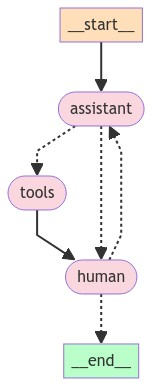

In [17]:
try:
    display(Image(part_1_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [18]:
def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message["role"] == "assistant":
            print(colored(f"\nAssistant: {message['content']}", "yellow"))
        # if message.id not in _printed:
        #     msg_repr = message.pretty_repr(html=True)
        #     if len(msg_repr) > max_length:
        #         msg_repr = msg_repr[:max_length] + " ... (truncated)"
        #     print(msg_repr)
        #     _printed.add(message.id)


# Let's create an example conversation a user might have with the assistant
tutorial_questions = [
    "Hi there, what time is my flight?",
    "Am i allowed to update my flight to something sooner? I want to leave later today?",
    "Update my flight to sometime next week then",
    "The next available option is great",
    "what about lodging and transportation?",
    "Yeah i think i'd like an affordable hotel for my week-long stay (7 days). And I'll want to rent a car.",
    "OK could you place a reservation for your recommended hotel? It sounds nice.",
    "yes go ahead and book anything that's moderate expense and has availability.",
    "Now for a car, what are my options?",
    "Awesome let's just get the cheapest option. Go ahead and book for 7 days",
    "Cool so now what recommendations do you have on excursions?",
    "Are they available while I'm there?",
    "interesting - i like the museums, what options are there? ",
    "OK great pick one and book it for my second day there.",
]

# Update with the backup file so we can restart from the original place in each section
shutil.copy(backup_file, db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "passenger_id": "3442 587242",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}


_printed = set()
question = tutorial_questions[0]
print(colored(f"\nUser: {question}", "cyan"))
events = part_1_graph.stream(
    {"messages": [system_template(), user_message(question)]},
    config=config,
    stream_mode="values",
)
for event in events:
    _print_event(event, _printed)


User: Hi there, what time is my flight?


AI MESSAGES:
{'role': 'system', 'content': "You are a helpful customer support assistant for Swiss Airlines.\nUse the provided tools to search for flights, company policies, accomodation, and other information to assist the user's queries.\n\nCurrent user:\n<User>\n{'passenger_id': '123'}\n</User>\nCurrent time: 2024-06-18 01:39:07.209351"}
{'role': 'user', 'content': 'Hi there, what time is my flight?'}





TOOLS MESSAGES:
{'role': 'system', 'content': "You are a helpful customer support assistant for Swiss Airlines.\nUse the provided tools to search for flights, company policies, accomodation, and other information to assist the user's queries.\n\nCurrent user:\n<User>\n{'passenger_id': '123'}\n</User>\nCurrent time: 2024-06-18 01:39:07.209351"}
{'role': 'user', 'content': 'Hi there, what time is my flight?'}
{'role': 'assistant', 'content': FetchUserFlightInformationTool(tool_name='fetch_user_flight_information')}




Assistant: tool_name=